In [222]:
import scipy
import numpy as np
import pandas as pd
import seaborn as sns
import seaborn.objects as so

# Para clustering
from sklearn.datasets import make_blobs
from sklearn.datasets import make_circles
from sklearn.preprocessing import MinMaxScaler, StandardScaler 
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

**Ejercicio 1**

Trabajamos con las variables "bill_length_mm" y "bill_depth_mm" de pinguinos.

1. Escalar las variables por Standard Scaler (KNN es sensible a las escalas)
2. Para cada uno de los pinguinos 15, 313 y 151 (ver slides), numerar en un gráfico los 9 pinguinos mas cercanos, ordenados de más cerca a más lejos.
3. Clasificar cada pingüino utilizando KNN con K = 1, 3 y 9.

In [64]:
# Utilizamos NearestNeighbors para obtener los vecinos más cercanos
from sklearn.neighbors import NearestNeighbors

In [72]:
# Eliminamos datos faltantes y reseteamos los índices, para no tener problemas al graficar
penguins = sns.load_dataset("penguins").dropna().reset_index(drop=True)

# Normalizamos las variables "bill_length_mm" y "bill_depth_mm" por MinMax
penguins[["bill_length_mm", "bill_depth_mm"]] = StandardScaler().fit_transform(penguins[["bill_length_mm", "bill_depth_mm"]])

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,-0.896042,0.780732,181.0,3750.0,Male
1,Adelie,Torgersen,-0.822788,0.119584,186.0,3800.0,Female
2,Adelie,Torgersen,-0.676280,0.424729,195.0,3250.0,Female
3,Adelie,Torgersen,-1.335566,1.085877,193.0,3450.0,Female
4,Adelie,Torgersen,-0.859415,1.747026,190.0,3650.0,Male


In [95]:
# Nos quedamos solo con largo y profundidad del pico
datos = penguins[["bill_depth_mm", "bill_length_mm"]]
datos

,bill_depth_mm,bill_length_mm
0,0.780732,-0.896042
1,0.119584,-0.822788
2,0.424729,-0.676280
3,1.085877,-1.335566
4,1.747026,-0.859415
...,...,...
328,-1.762145,0.587352
329,-1.457000,0.514098
330,-0.744994,1.173384
331,-1.202712,0.221082


In [96]:
# Veamos primero los 9 vecinos más cercanos del pingüino 151
K = 9
ind = 313
neighbors = NearestNeighbors(n_neighbors=K+1)  # Esta función nos devuelve los más cercanos incluyendo a si mismo, por eso tomamos 10.
neighbors.fit(datos)  # En el ajuste solamente almacenamos los datos

NearestNeighbors(n_neighbors=10)

In [98]:
# Cómo se guardan los datos??

# Podemos ver todos los atributos (variables) de una clase usando __dict__
neighbors.__dict__

{'n_neighbors': 10,
 'radius': 1.0,
 'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'p': 2,
 'n_jobs': None,
 'feature_names_in_': array(['bill_depth_mm', 'bill_length_mm'], dtype=object),
 'n_features_in_': 2,
 'effective_metric_params_': {},
 'effective_metric_': 'euclidean',
 '_fit_method': 'kd_tree',
 '_fit_X': array([[ 7.80732104e-01, -8.96041890e-01],
        [ 1.19583967e-01, -8.22787867e-01],
        [ 4.24729261e-01, -6.76279821e-01],
        [ 1.08587740e+00, -1.33556603e+00],
        [ 1.74702554e+00, -8.59414878e-01],
        [ 3.23014163e-01, -9.32668901e-01],
        [ 1.23845005e+00, -8.77728384e-01],
        [ 2.21299065e-01, -5.29771775e-01],
        [ 2.05217083e+00, -9.87609419e-01],
        [ 2.00131328e+00, -1.72014965e+00],
        [ 3.23014163e-01, -1.35387953e+00],
        [ 9.33304752e-01, -9.69295913e-01],
        [ 1.79788309e+00, -2.73382694e-01],
        [ 6.28159457e-01, -1.75677666e+00],
        [ 2.20474348e+00,  

In [100]:
# Ahora podemos buscar los vecinos más cercanos a un punto cualquiera o un conjunto de puntos.
# Tenemos que pasarle un DataFrame
distances, indices = neighbors.kneighbors(datos.iloc[[ind]])

In [103]:
# Nos devuelve un vector de distancias (opcional)
distances

array([[0.        , 0.52925763, 0.55985707, 0.67759971, 0.6795056 ,
        0.69591322, 0.72317031, 0.76293506, 0.88093269, 0.9072404 ]])

In [104]:
# Lo convertimos a vector
distances.flatten()

array([0.        , 0.52925763, 0.55985707, 0.67759971, 0.6795056 ,
       0.69591322, 0.72317031, 0.76293506, 0.88093269, 0.9072404 ])

Vemos que las distancias están ordenadas de menor a mayor.

In [105]:
# Y un vector de índices

In [106]:
indices.flatten()

array([313, 326, 163, 246, 303, 301, 276, 318, 324, 159], dtype=int64)

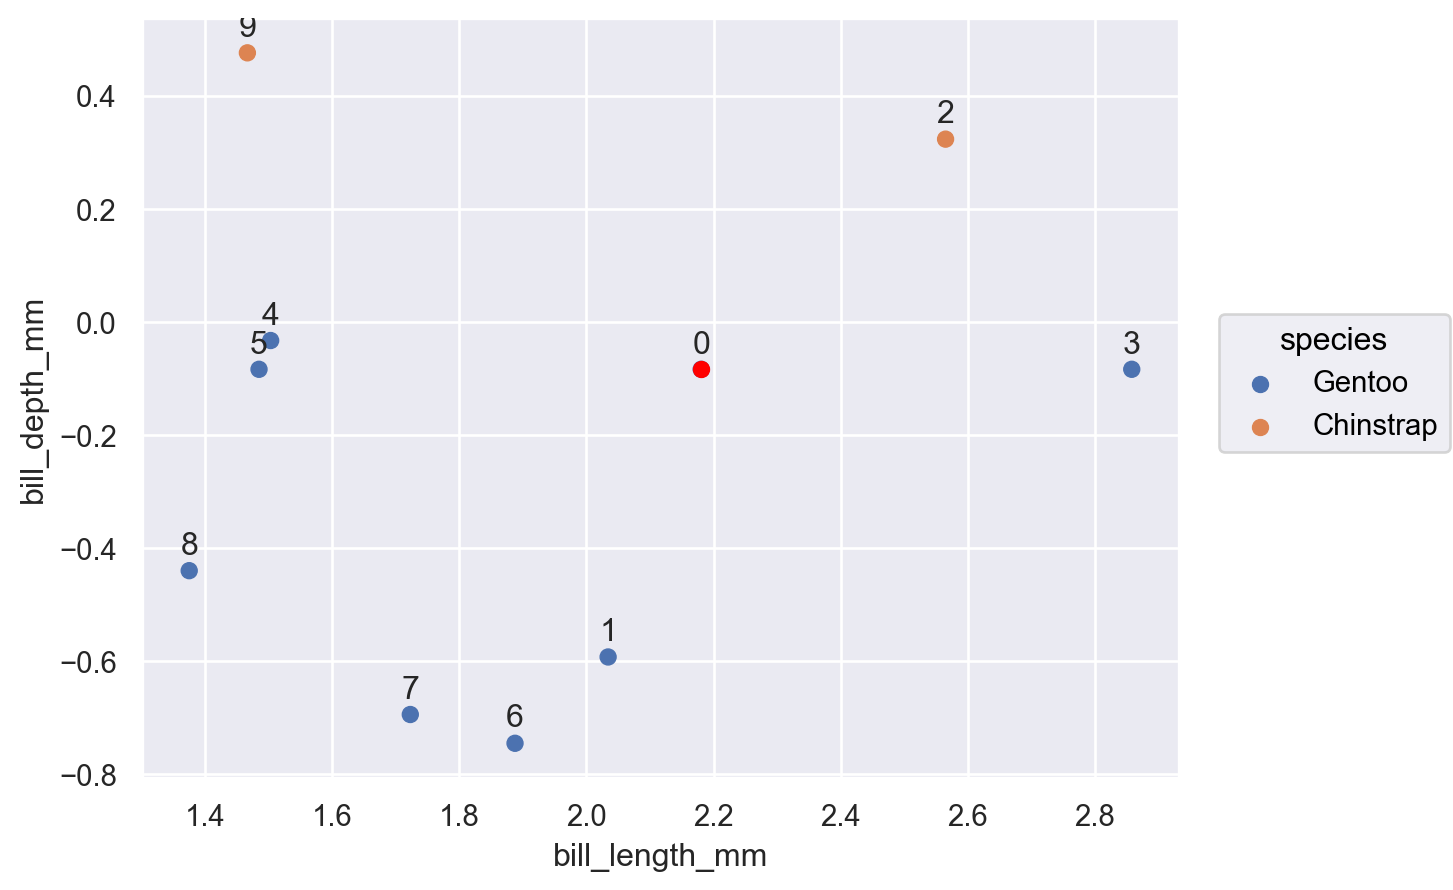

In [78]:
# Graficamos
# Utilizamos un nuevo canal para codificar información: texto o etiquetas en cada punto
(
    so.Plot(data = penguins.iloc[indices.flatten()], x = "bill_length_mm", y = "bill_depth_mm",  text = np.arange(K+1).astype(str))
    .add(so.Text(valign = "bottom"))
    .add(so.Dot(), color = "species")
    .add(so.Dot(color = "red"), data = penguins.iloc[[ind]], x = "bill_length_mm", y = "bill_depth_mm")
)

**Ejercicio 2**

1. Implementar una función que reciba un DataFrame (que tenga solo las variables numéricas a utilizar para medir distancias), un vector de categorías (indexado igual que el DataFrame), un índice y un valor de K y devuelva la predicción por KNN para el dato indicado. Importante: debemos ignorar al propio dato en la votación.
2. Aplicar la función a los datos de pingüinos.

**Sugerencia:** para elegir la categoría más votada podemos calcular la moda. El paquete statistics provee el comando `mode`.


In [113]:
# Cargamos el comando mode
import statistics
from statistics import mode

In [114]:
# Item 1

# Antes de hacer la función lo calculamos para un ejemplo.
K = 9
ind = 151
datos = penguins[["bill_depth_mm", "bill_length_mm"]]
categorias = penguins["species"]

In [115]:
# Cargamos los datos en neighbors
neighbors = NearestNeighbors(n_neighbors= K)  # Vamos a eliminar al propio pinguino de los datos, por eso tomamos K.
neighbors.fit(datos.drop([ind]))

NearestNeighbors(n_neighbors=9)

In [118]:
distances, indices = neighbors.kneighbors(datos.iloc[[ind]])
votos = categorias[indices.flatten()]
votos

173    Chinstrap
123       Adelie
186    Chinstrap
146    Chinstrap
155    Chinstrap
151    Chinstrap
197    Chinstrap
169    Chinstrap
249       Gentoo
Name: species, dtype: object

In [117]:
mode(votos)

'Chinstrap'

In [120]:
# Juntamos todo en una función
def mas_votado(datos, categorias, ind, K):
    neighbors = NearestNeighbors(n_neighbors= K)  # Vamos a eliminar al propio pinguino de los datos, por eso tomamos K.
    neighbors.fit(datos.drop([ind]))

    distances, indices = neighbors.kneighbors(datos.iloc[[ind]])
    votos = categorias[indices.flatten()]

    return(mode(votos))

In [121]:
# Item 2 - Aplicamos la función a los datos de pingüinos
datos = penguins[["bill_depth_mm", "bill_length_mm"]]
categorias = penguins["species"]
mas_votado(datos, categorias, 313, 9)

'Gentoo'

**Ejercicio 3**
1. Implementar una función que reciba un DataFrame, un vector de categorías y un valor de K y calcule las predicciones para todos los datos y nos devuelva el porcentaje de aciertos.
2. Aplicar la función a los datos de pingüinos.

In [53]:
# Item 1
def knn_leave_one_out(datos, categorias, K):
    correctos = 0
    total = len(datos)
    for ind in range(total):
        prediccion = mas_votado(datos, categorias, ind, K)
        if(categorias[ind] == prediccion):
            correctos += 1
    return(correctos / total)

In [55]:
# Item 2 - Aplicamos la función a los datos de pingüinos
datos = penguins[["bill_depth_mm", "bill_length_mm"]]
categorias = penguins["species"]
knn_leave_one_out(datos, categorias, 9)

0.960960960960961

**Ejercicio 4**
Utilizando las funciones de los ejercicios anteriores, calcular el valor de $K$ (impar) óptimo para predecir la especie de un pingüino.

In [59]:
for K in range(1,30,2):
    aciertos = knn_leave_one_out(datos, categorias, K)
    print(K, aciertos)

1 0.93993993993994
3 0.9579579579579579
5 0.963963963963964
7 0.9579579579579579
9 0.960960960960961
11 0.96996996996997
13 0.9669669669669669
15 0.963963963963964
17 0.963963963963964
19 0.960960960960961
21 0.9579579579579579
23 0.9579579579579579
25 0.954954954954955
27 0.960960960960961
29 0.954954954954955


## Ejemplo: detección temprana de diabetes

A partir de distintos datos de pacientes queremos detectar tempranamente si ese paciente va a sufrir diabetes.

Utilizamos ahora la función de sklean: KNeighborsClassifier

1. Leer los datos del archivo "diabetes.csv".
2. Separar la columna "Outcome" como variable respuesta y el resto como variables explicativas.
3. Partir la muestra en un 80% para entrenamiento y un 20% para testeo.
4. Escalar las variables explicativas por StandardScaler
5. Se quiere predecir la variable respuesta por KNN. Calcular el valor óptimo de $K$ optimizando el porcentaje de aciertos en testeo.
7. Para el valor hallado, calcular la matriz de confusión en testeo (es la matriz $C$ que guarda en la coordenada $C_{ij}$ la cantidad de observaciones en el grupo $i$ que fueron clasificadas en el grupo $j$).

In [132]:
# Utilizamos estos paquetes
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [133]:
datos = pd.read_csv("../Datos/diabetes.csv")
datos.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [134]:
# 2. Separamos la variable respuesta
X = datos.drop("Outcome",axis=1)
y = datos["Outcome"]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age
0,0.639947,0.848324,0.149641,0.907270,-0.692891,0.204013,0.468492,1.425995
1,-0.844885,-1.123396,-0.160546,0.530902,-0.692891,-0.684422,-0.365061,-0.190672
2,1.233880,1.943724,-0.263941,-1.288212,-0.692891,-1.103255,0.604397,-0.105584
3,-0.844885,-0.998208,-0.160546,0.154533,0.123302,-0.494043,-0.920763,-1.041549
4,-1.141852,0.504055,-1.504687,0.907270,0.765836,1.409746,5.484909,-0.020496
...,...,...,...,...,...,...,...,...
763,1.827813,-0.622642,0.356432,1.722735,0.870031,0.115169,-0.908682,2.532136
764,-0.547919,0.034598,0.046245,0.405445,-0.692891,0.610154,-0.398282,-0.531023
765,0.342981,0.003301,0.149641,0.154533,0.279594,-0.735190,-0.685193,-0.275760
766,-0.844885,0.159787,-0.470732,-1.288212,-0.692891,-0.240205,-0.371101,1.170732


In [188]:
# 3. Separamos en entrenamiento y validación
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [189]:
# 4. Escalamos X
scaler = StandardScaler().set_output(transform="pandas")
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [190]:
neighbor = KNeighborsClassifier(n_neighbors=5)

In [191]:
# Entrenamos utilizando X_train
neighbor.fit(X_train_scaled,y_train)

KNeighborsClassifier()

In [192]:
# Predecimos utilizando X_test
y_pred = neighbor.predict(X_test_scaled)
y_pred

array([0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1],
      dtype=int64)

In [193]:
# Calculamos la precisión con accuracy_score (porcentaje de aciertos)
print(accuracy_score(y_test,y_pred))

0.7402597402597403


In [194]:
# Como lo podemos hacer a mano?
np.sum(y_test == y_pred) / len(y_test)

0.7402597402597403

In [195]:
# Repetimos todo para varios valores de K
for K in range(1,30,2):
    neighbor = KNeighborsClassifier(n_neighbors=K)
    neighbor.fit(X_train_scaled,y_train)
    y_pred = neighbor.predict(X_test_scaled)
   
    print(K, accuracy_score(y_test,y_pred))

1 0.7337662337662337
3 0.7012987012987013
5 0.7402597402597403
7 0.7272727272727273
9 0.7207792207792207
11 0.7142857142857143
13 0.7207792207792207
15 0.7272727272727273
17 0.7207792207792207
19 0.7207792207792207
21 0.7207792207792207
23 0.7207792207792207
25 0.7207792207792207
27 0.7012987012987013
29 0.6883116883116883


**Matriz de confusión**
La matriz de confusión $C$ guarda en la coordenada $C_{ij}$ la cantidad de observaciones en el grupo $i$ que fueron clasificadas en el grupo $j$.

Si la variable es binaria:
- $C_{00}$ son los casos negativos clasificados correctamente.
- $C_{01}$ son los casos negativos  clasificados como positivos (falsos positivos).
- $C_{10}$ son los casos positivos  clasificados como negativos (falsos negativos).
- $C_{11}$ son los casos positivos clasificados correctamente.

In [196]:
K = 5
neighbor = KNeighborsClassifier(n_neighbors=K)
neighbor.fit(X_train_scaled,y_train)
y_pred = neighbor.predict(X_test_scaled)

print(K, accuracy_score(y_test,y_pred))

5 0.7402597402597403


In [197]:
C = confusion_matrix(y_test,y_pred)
display(C)

array([[75,  9],
       [31, 39]], dtype=int64)

**Ejercicio:** Calcular el coeficiente $C_{01}$ a mano.

In [198]:
sum((y_pred==1) & (y_test==0))

9

In [200]:
# Si solo nos interesa evaluar el desempeño podemos usar score en lugar de predict
neighbor.fit(X_train_scaled,y_train).score(X_test_scaled,y_test)

0.7402597402597403

In [181]:
neighbor

KNeighborsClassifier(n_neighbors=3)

**Ejercicio:** Utilizar KNeighborsClassifier con validación por leave-one-out.
En este caso podemos utilizar la función predict con parámetro None, y realiza las predicciones sobre el conjunto de entrenamiento, dejando siempre a la propia observacion afuera al hacer la predicción. Esto corresponde a validación leave-one-out.

In [187]:
scaler = StandardScaler().set_output(transform="pandas")
X_scaled = scaler.fit_transform(X)

for K in range(1,30,2):
    neighbor = KNeighborsClassifier(n_neighbors=K)
    neighbor.fit(X_scaled,y)
    y_pred = neighbor.predict(None)
   
    print(K, accuracy_score(y,y_pred))

1 0.70703125
3 0.7356770833333334
5 0.7421875
7 0.7395833333333334
9 0.7395833333333334
11 0.7486979166666666
13 0.7369791666666666
15 0.7369791666666666
17 0.7447916666666666
19 0.7421875
21 0.7591145833333334
23 0.7604166666666666
25 0.7578125
27 0.74609375
29 0.74609375


**Extra:** Según la teoría, si aumentamos la cantidad de variables explicativas (y por lo tanto la dimensión de espacio de "features"), los puntos tienden a estar a distancias similares, es decir, disminuye la varianza de las distancias entre puntos.

Hagamos una simulación para verificarlo...

In [204]:
import numpy as np
from scipy.spatial.distance import pdist

def distancia_varianza(n, num_puntos=100):
    # Generar puntos aleatorios en [0,1]^n
    puntos = np.random.rand(num_puntos, n)
    
    # Calcular todas las distancias euclidianas por pares (sin repetir)
    distancias = pdist(puntos, metric='euclidean')

    # Calcular y devolver la varianza de las distancias
    return np.mean(distancias)

# Ejemplo: calcular para dimensiones 1 a 20
for n in range(1, 20):
    var = distancia_varianza(n)
    print(f"Dimensión {n:2d} -> Varianza de distancias: {var:.6f}")

Dimensión  1 -> Varianza de distancias: 0.356633
Dimensión  2 -> Varianza de distancias: 0.522977
Dimensión  3 -> Varianza de distancias: 0.658589
Dimensión  4 -> Varianza de distancias: 0.790684
Dimensión  5 -> Varianza de distancias: 0.888580
Dimensión  6 -> Varianza de distancias: 0.939940
Dimensión  7 -> Varianza de distancias: 1.031961
Dimensión  8 -> Varianza de distancias: 1.112768
Dimensión  9 -> Varianza de distancias: 1.188321
Dimensión 10 -> Varianza de distancias: 1.280424
Dimensión 11 -> Varianza de distancias: 1.332628
Dimensión 12 -> Varianza de distancias: 1.379482
Dimensión 13 -> Varianza de distancias: 1.494108
Dimensión 14 -> Varianza de distancias: 1.483283
Dimensión 15 -> Varianza de distancias: 1.580942
Dimensión 16 -> Varianza de distancias: 1.606518
Dimensión 17 -> Varianza de distancias: 1.656566
Dimensión 18 -> Varianza de distancias: 1.718514
Dimensión 19 -> Varianza de distancias: 1.794871


In [203]:
# Qué pasó...? No disminuye la varianza??

In [220]:
n = 200
num_puntos = 100
puntos = np.random.rand(num_puntos, n)
    
# Calcular todas las distancias euclidianas por pares (sin repetir)
distancias = pdist(puntos, metric='euclidean')

In [221]:
# Option 2: Using np.inf
np.set_printoptions(threshold=np.inf)  # Para ver todas las coordenadas
distancias

array([6.02979919, 5.72884545, 5.99020605, 5.8583761 , 5.69546374,
       6.24637093, 5.81378014, 6.07151871, 5.81932349, 5.92219543,
       5.93210777, 5.94317687, 5.9280804 , 5.79951946, 5.67170037,
       5.66018135, 5.75273451, 5.78714995, 5.65290641, 5.95727946,
       5.70733109, 6.38074292, 5.91052062, 5.63650399, 5.89887144,
       6.03054941, 5.85396103, 5.94368712, 5.90029352, 5.7214494 ,
       6.0859771 , 5.60061111, 5.78706633, 5.94893456, 5.71643367,
       5.72615869, 5.46207351, 5.57898785, 5.71342982, 5.8173907 ,
       6.19912453, 5.87490791, 6.15614802, 5.79739338, 5.93690987,
       5.87519849, 5.91201819, 6.0173867 , 6.03068427, 6.15353821,
       6.21421402, 5.75611981, 5.90026786, 6.06938619, 5.70341094,
       5.48168011, 5.77278696, 5.62981364, 5.70477238, 5.99796219,
       5.85176481, 5.95842596, 5.82041978, 5.59460195, 5.7694475 ,
       6.09193692, 5.92507409, 5.89185552, 5.77547072, 5.82368962,
       5.81849813, 5.60235205, 6.11037406, 5.89168294, 5.63738